<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/04_seminar_note_5_1_anomaly_detection_supervised_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <font color='dark gary'> Anomaly detection method
https://scikit-learn.org/stable/modules/outlier_detection.html#outlier-detection
<img src = 'https://sdk.finance/wp-content/uploads/2021/04/anomaly_detection-768x512.png'>

### 1. Supervised learning
### 2. Semi-Supervised learning (Novelty detection)
- 새로운 한번도 보지 못한 데이터가 outlier인지 아닌지 판단(훈련데이터에 outlier가 없음)
### 3. Unsupervised learning (Outlier detection)
- inlier와 outlier를 포함한 훈련데이터에서 outliers를 탐색
        * Anomaly는 outlier와 novelty를 모두 호칭

https://github.com/yzhao062/anomaly-detection-resources
- 응용 분야
     * Data cleaning
     * Fraud detection like credit card frauds or security breaches
     * Health monitoring of people, systems, and machines

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

# <font color='red'> 1. Supervised Learning

In [ ]:
from sklearn.datasets import fetch_california_housing
housing_dataset = fetch_california_housing()
housing = pd.DataFrame(housing_dataset.data, columns=housing_dataset.feature_names)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1.1 Interquartile Range(IQR) - Box plot으로 outlier 탐색
단일 변수의 백분위수 (range)를 확인하여 이상치(outlier)를 그려보고 확인한다

In [ ]:
housing.skew().sort_values(ascending=False)
housing.kurt().sort_values(ascending=False)

,0
AveOccup,97.639561
AveBedrms,31.316956
AveRooms,20.697869
Population,4.935858
MedInc,1.646657
Latitude,0.465953
HouseAge,0.060331
Longitude,-0.297801


,0
AveOccup,10651.010636
AveBedrms,1636.711972
AveRooms,879.353264
Population,73.553116
MedInc,4.952524
HouseAge,-0.800629
Latitude,-1.117760
Longitude,-1.330152


In [ ]:
housing.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

<Axes: >

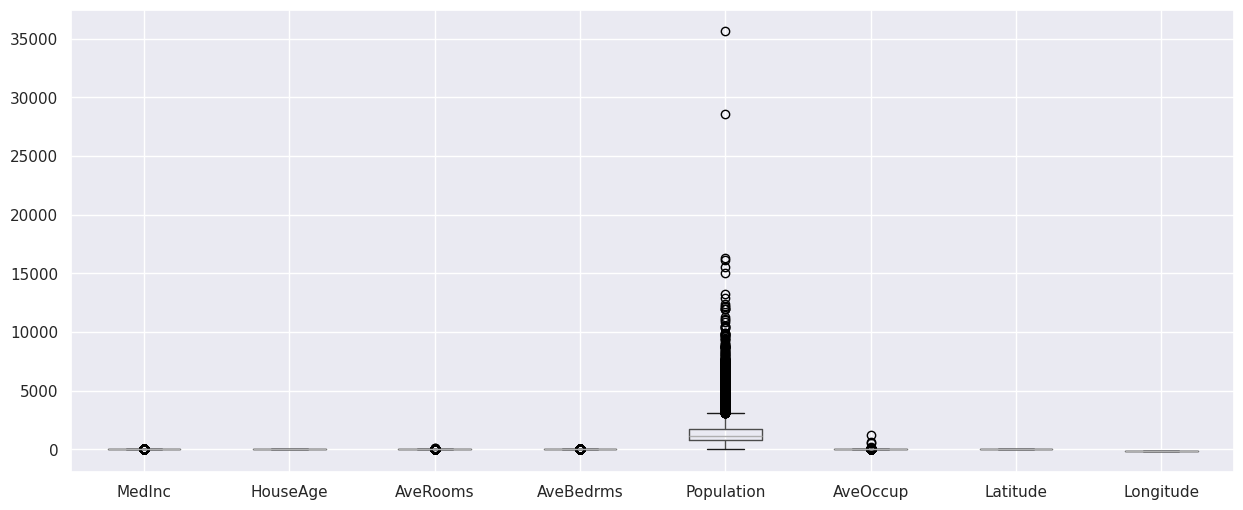

In [ ]:
housing.boxplot(figsize=(15,6))

<Axes: >

Text(0.5, 1.0, 'Box Plot of Standardized Housing Data')

Text(0, 0.5, 'Standardized Value')

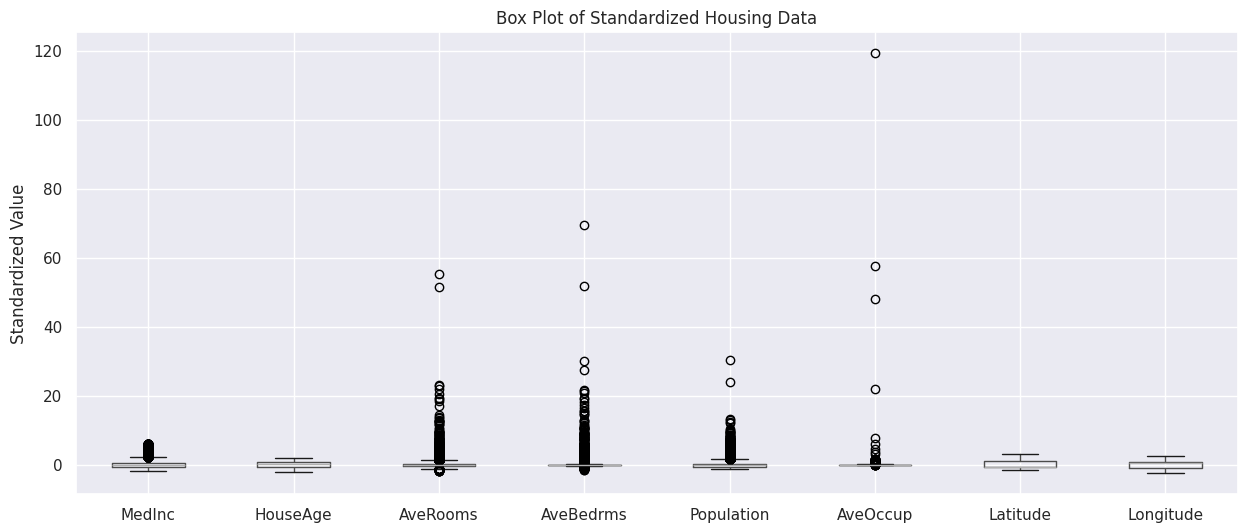

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the housing data
housing_scaled = scaler.fit_transform(housing)

# Create a new DataFrame with scaled data and original column names
housing_scaled_df = pd.DataFrame(housing_scaled, columns=housing.columns)

# Visualize the scaled data with a box plot
housing_scaled_df.boxplot(figsize=(15, 6))
plt.title('Box Plot of Standardized Housing Data')
plt.ylabel('Standardized Value')
plt.show()

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

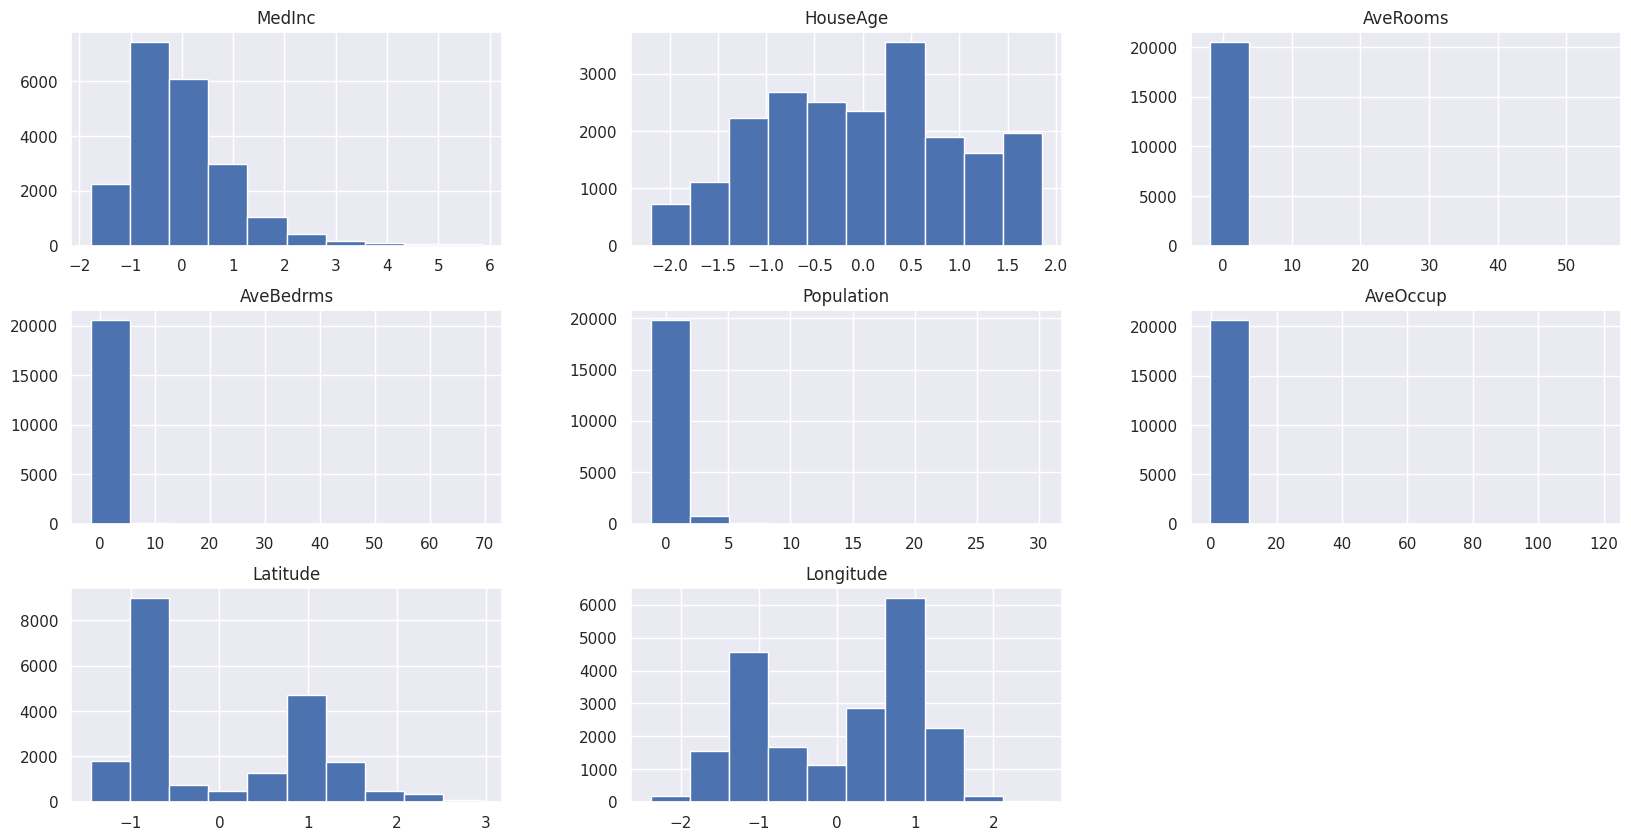

In [ ]:
housing_scaled_df.hist(figsize=(20,10))

<Axes: >

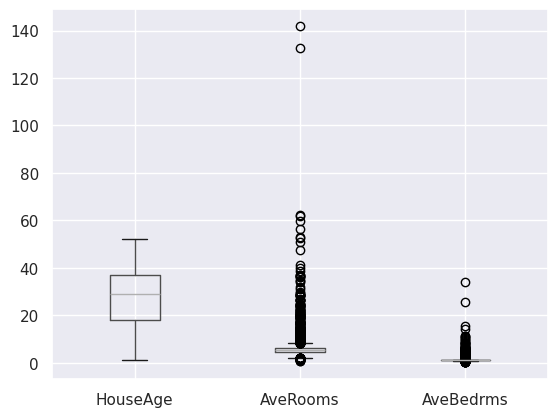

In [ ]:
cols = ['HouseAge', 'AveRooms', 'AveBedrms']
housing.boxplot(column=cols)

In [ ]:
def Outliers(col):
    q1, q3 =col.quantile(0.15), col.quantile(0.95)
    iqr = q3 - q1
    l_fence, u_fence = q1 - 1.5*iqr , q3 + 1.5*iqr
    outliers = col[(col < l_fence) | (col > u_fence)]
    if outliers.count() > 0 :
        print(col.name,'의 총 이상치 관측 수:', outliers.count())
        print('Lower fence: ', l_fence, 'Upper fence: ', u_fence) #filtering = col.drop(outliers.index, axis = 0)
for col in housing.columns:
    Outliers(housing[col])

AveRooms 의 총 이상치 관측 수: 131
Lower fence:  -1.3340476467284645 Upper fence:  13.024823063957758
AveBedrms 의 총 이상치 관측 수: 344
Lower fence:  0.5474330404385597 Upper fence:  1.708349323887693
Population 의 총 이상치 관측 수: 96
Lower fence:  -3377.3750000000005 Upper fence:  7287.225
AveOccup 의 총 이상치 관측 수: 64
Lower fence:  -0.9312670180671154 Upper fence:  7.492226877506934


## 1.2 확률밀도함수로 이상치 확인

단일변수의 확률밀도 함수를 확인하여 이상치를 p-value로 확인한다

z = 1.96의 pdf: 0.942, z = 2.58의 pdf: 0.986


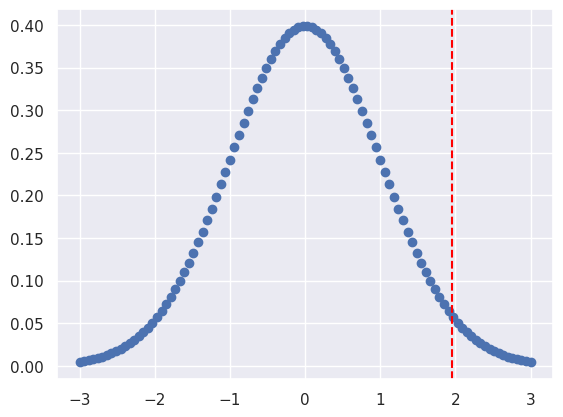

In [ ]:
import scipy as sp
sp.stats.norm(loc=0, scale=1) # 평균0, 표준편차 1
rv = sp.stats.norm(loc=0, scale=1)
print(f'z = 1.96의 pdf: {1- rv.pdf(1.96):.3f}, z = 2.58의 pdf: {1- rv.pdf(2.58):.3f}')
plt.scatter(np.linspace(-3,3,100), rv.pdf(np.linspace(-3,3,100)))
plt.axvline(x=1.96, color='red', linestyle='--')

Text(0.5, 0, 'instances')

Text(0, 0.5, 'pdf(probability density function)')

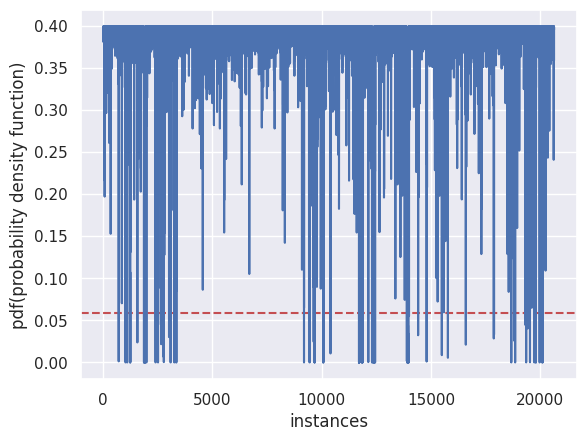

In [ ]:
z = (housing['AveBedrms'] - housing['AveBedrms'].mean())/housing['AveBedrms'].std()
plt.axhline(y= rv.pdf(1.96), color='r', linestyle='--')
plt.plot(rv.pdf(z))
plt.xlabel('instances'); plt.ylabel('pdf(probability density function)')

가우시안 분포를 가정하여 pdf(probability density distribution)이 임계치를 넘으면 이상치라고 판단

## 1.3 K-Nearest neighbors 이상치 확인
- Unsupervised K-Nearest Neighbors
- 선행 학습 : https://scikit-learn.org/stable/modules/neighbors.html
- SVM도 SVM hyperplane에서 거리를 기준으로 이상치 확인 가능

In [ ]:
housing[['AveBedrms', 'AveOccup']]

,AveBedrms,AveOccup
0,1.023810,2.555556
1,0.971880,2.109842
2,1.073446,2.802260
3,1.073059,2.547945
4,1.081081,2.181467
...,...,...
20635,1.133333,2.560606
20636,1.315789,3.122807
20637,1.120092,2.325635
20638,1.171920,2.123209


NearestNeighbors(n_neighbors=3)

<Axes: >

Text(0.5, 1.0, 'Distance mean of KNN')

Text(0.5, 0, 'Instances')

Text(0, 0.5, 'Mean of Distance')

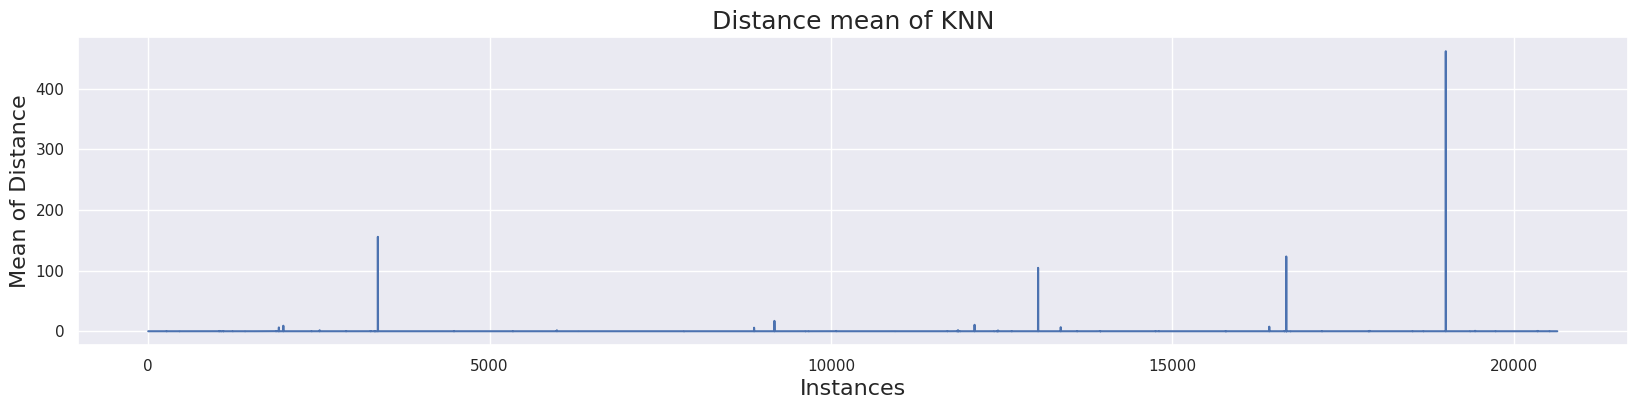

In [ ]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors = 3)
nbrs.fit(housing[['AveBedrms', 'AveOccup']])
distances, indices = nbrs.kneighbors(housing[['AveBedrms', 'AveOccup']]) # distances : distances between data points
                                           # indices : associated index values
pd.Series(distances.mean(axis =1)).plot(figsize=(20,4))
plt.title('Distance mean of KNN', fontsize = 18)
plt.xlabel('Instances', fontsize = 16); plt.ylabel('Mean of Distance', fontsize = 16)

### Spike 되는 instance는 anomaly이며, 평균 거리가 '100.0'이상이면 이상치라고 판단

In [ ]:
outlier_index = np.where(distances.mean(axis = 1) > 100.0)
housing.iloc[outlier_index]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98


### 불균형데이터 유형
- 이상치는 극히 심한 불균형데이터와 같은 유형을 갖는다.
- make_classification() 함수에 클라스를 무작위로 교환하여 분류를 어렵게 함, flip_y=0

### 단변량으로 시각화하면 이상치를 발견하기 어려움

<Figure size 2000x500 with 0 Axes>

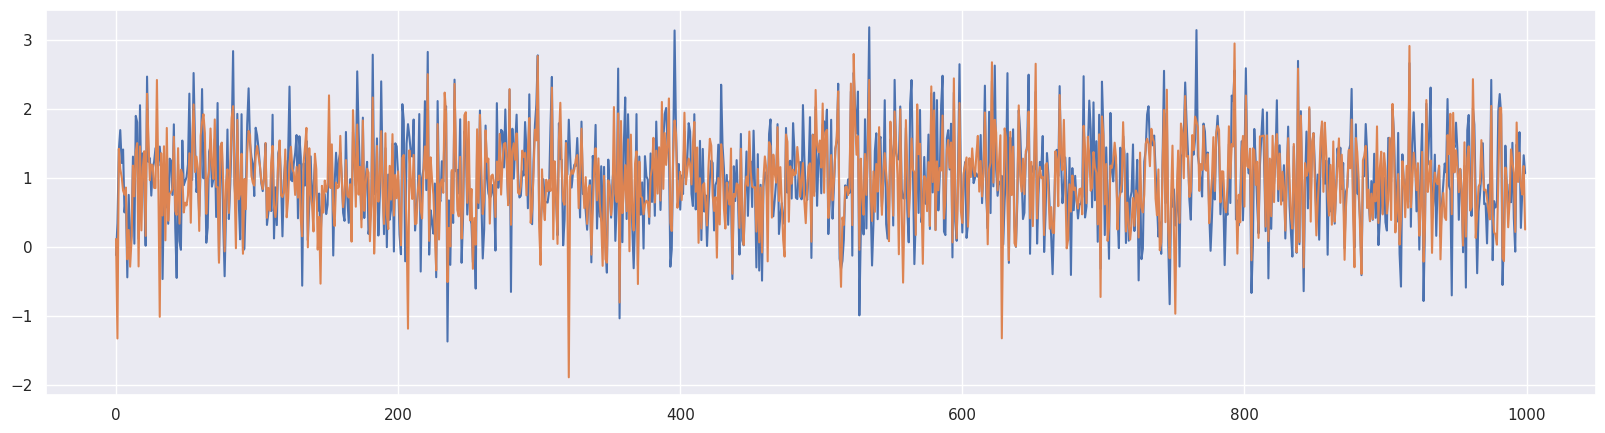

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
plt.figure(figsize=(20,5))
plt.plot(X[:, 0]); plt.plot(X[:, 1])

### 다변량, combination으로 시각화하면 이상치를 발견할 수있음

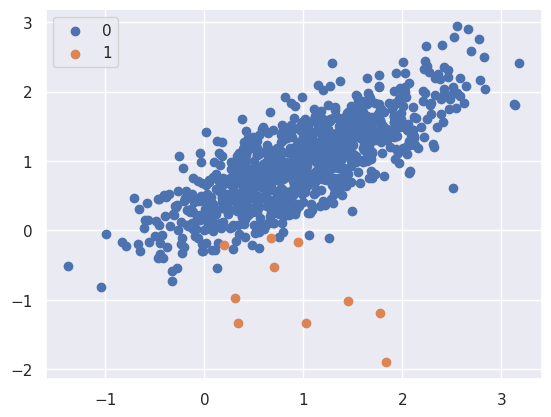

In [ ]:
from collections import Counter
for label, _ in Counter(y).items():
    row_ix = np.where(y == label)[0]
    plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()

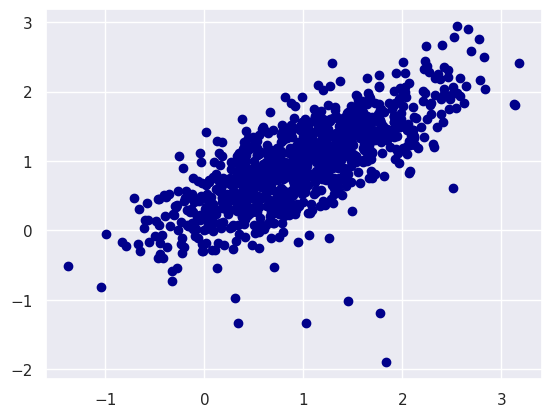

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c='darkblue')
plt.show()

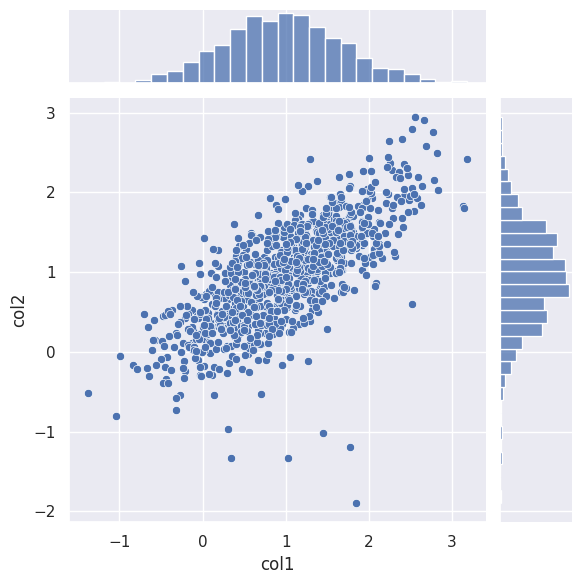

In [ ]:
data= pd.DataFrame(X, columns=['col1', 'col2'])
sns.jointplot(data=data, x='col1', y='col2')

### PCA anomaly

Text(0.5, 0, 'Number of PC')

Text(0, 0.5, 'Cumulative Explained Variance Ratio')

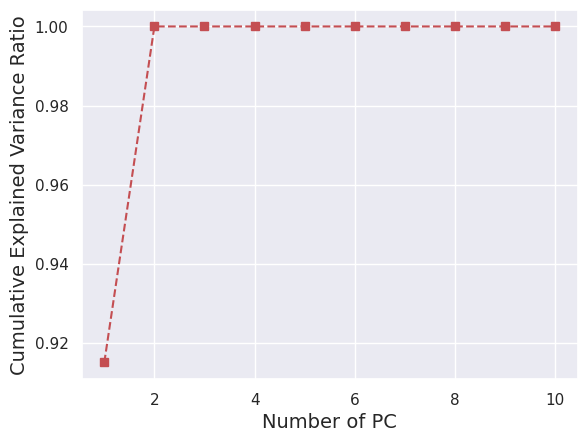

In [ ]:
from sklearn.decomposition import PCA
X, y = make_classification(n_samples=1000, n_features=10, n_redundant=8,
                           n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
pca = PCA().fit(X)
plt.plot(np.arange(1, X.shape[1]+1), np.cumsum(pca.explained_variance_ratio_), 'rs--')
plt.xlabel('Number of PC', fontsize='14'); plt.ylabel('Cumulative Explained Variance Ratio', fontsize='14')

In [ ]:
X_pca = PCA(n_components=2).fit(X).transform(X)
X_pca = pd.DataFrame(X_pca, columns= ['pca_1', 'pca_2'])

Text(0.5, 0, 'Principal Component 1')

Text(0, 0.5, 'Principal Component 2')

Text(0.5, 1.0, 'PCA Transformed Data (2 Components)')

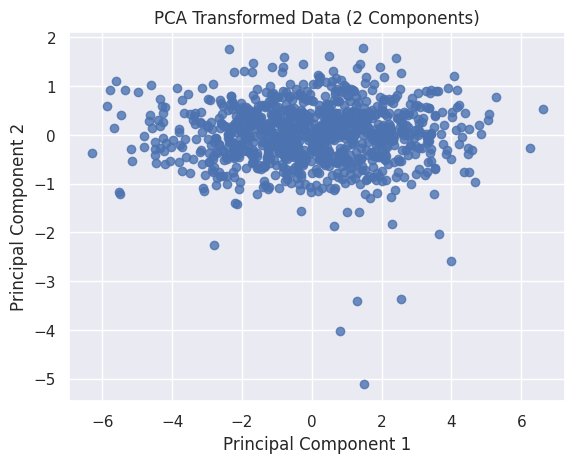

In [ ]:
plt.scatter(X_pca['pca_1'], X_pca['pca_2'], alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Data (2 Components)')
plt.grid(True)
plt.show()